<a href="https://colab.research.google.com/github/AlonsoVento/Portafolio_Python_MarioAlonsoVentoAlvarado/blob/master/Portafolio_Python_An%C3%A1lisisDatos_MarioAlonsoVentoAlvarado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Portafolio Python - Análisis de Datos: Mario Alonso Vento Alvarado**

### **Objetivo del caso**
Se desarrollará un análisis exploratorio de datos (EDA) completo sobre un dataset real.
El objetivo no es realizar modelos de predicción o calcular KPIs, sino analizar, limpiar, transformar y visualizar los datos para identificar patrones relevantes que puedan servir en la toma de decisiones.

### **Contexto del dataset**
Se entrega el archivo BankMarketing.csv, correspondiente a una institución financiera que busca entender los factores que influyen en la aceptación de sus campañas de
marketing.
Durante los últimos 6 meses, la efectividad (e = (Ventas/Base)×100%) cayó de 12% a 8%, afectando los bonos de los ejecutivos comerciales.

Se analizarán los datos de la última campaña para descubrir relaciones y comportamientos relevantes entre las variables.


## 1. Importación de librerías

In [35]:
# Importar librería necesarias
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

## 2. Carga del dataset

In [36]:
# Cargar el archivo  BankMarketing.csv con Pandas.
df = pd.read_csv('/content/sample_data/BankMarketing.csv', delimiter=';')

## 3. Exploración inical

In [37]:
# Analizar su estructura: .shape, .info(), .head(), .describe(), .isnull()
# Identificar valores nulos, inconsistencias o tipos de datos incorrectos.

In [38]:
print("Shape del DataFrame:")
display(df.shape)

Shape del DataFrame:


(41188, 21)

In [39]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

None

In [40]:
print("Head del DataFrame:")
display(df.head())

Head del DataFrame:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [41]:
print("Estadísticas Descriptivas del DataFrame:")
display(df.describe())

Estadísticas Descriptivas del DataFrame:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [42]:
print("Cantidad de valores null por columna:")
display(df.isnull().sum())

Cantidad de valores null por columna:


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


## 4. Funciones para clasificación de variables

In [43]:
# Identifique las columnas de tipo numérico (int, float).
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Columnas numéricas:", numerical_cols)

Columnas numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [44]:
# Identifique las columnas de tipo categórico (object o category).
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Columnas categóricas:", categorical_cols)

Columnas categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


## 5. Clase DataProcessor

In [45]:
# Implementar una clase llamada DataProcessor con los siguientes métodos:
# - __init__() para inicializar el dataset.
# - claen_data()
# - describe_numerical()
# - describe_categorical()
# - visualize_distributions()

In [46]:
class DataProcessor:
    def __init__(self, df):
        self.df = df
        self.numerical_cols = df.select_dtypes(include=['int64', 'float64', 'int', 'float']).columns.tolist()
        self.categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

    def describe_numerical(self):
        """Devuelve estadísticas descriptivas para variables numéricas."""
        print("\n--- Estadísticas descriptivas para variables numéricas ---")
        return self.df[self.numerical_cols].describe()

    def describe_categorical(self):
        """Muestra el número y la proporción de categorías únicas para variables categóricas."""
        print("\n--- Conteo y proporción de categorías únicas para variables categóricas. ---")
        for col in self.categorical_cols:
            print(f"\nColumna: {col}")
            counts = self.df[col].value_counts()
            proportions = self.df[col].value_counts(normalize=True).mul(100).round(2)
            description_df = pd.DataFrame({'Conteo': counts, 'Proporción (%)': proportions})
            print(description_df)

    def visualize_distributions(self):
        """Genera histogramas para variables numéricas y diagramas de barras para variables categóricas."""
        print("\n--- Visualización de distribuciones ---")

        # Histograms for numerical variables
        for col in self.numerical_cols:
            plt.figure(figsize=(8, 5))
            sns.histplot(self.df[col].dropna(), kde=True)
            plt.title(f'Distribución de {col}')
            plt.xlabel(col)
            plt.ylabel('Frecuencia')
            plt.show()

        # Bar plots for categorical variables
        for col in self.categorical_cols:
            plt.figure(figsize=(10, 6))
            sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')
            plt.title(f'Conteo de {col}')
            plt.xlabel('Conteo')
            plt.ylabel(col)
            plt.tight_layout()
            plt.show()

In [47]:
data_processor = DataProcessor(df)

In [48]:
print("\n--- Análisis de Frecuencias de Variables Categóricas ---")
data_processor.describe_categorical()


--- Análisis de Frecuencias de Variables Categóricas ---

--- Conteo y proporción de categorías únicas para variables categóricas. ---

Columna: job
               Conteo  Proporción (%)
job                                  
admin.          10422           25.30
blue-collar      9254           22.47
technician       6743           16.37
services         3969            9.64
management       2924            7.10
retired          1720            4.18
entrepreneur     1456            3.54
self-employed    1421            3.45
housemaid        1060            2.57
unemployed       1014            2.46
student           875            2.12
unknown           330            0.80

Columna: marital
          Conteo  Proporción (%)
marital                         
married    24928           60.52
single     11568           28.09
divorced    4612           11.20
unknown       80            0.19

Columna: education
                     Conteo  Proporción (%)
education                             

In [49]:
data_processor.df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


In [50]:
data_processor.numerical_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

In [51]:
data_processor.describe_numerical()


--- Estadísticas descriptivas para variables numéricas ---


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [52]:
data_processor.describe_categorical()


--- Conteo y proporción de categorías únicas para variables categóricas. ---

Columna: job
               Conteo  Proporción (%)
job                                  
admin.          10422           25.30
blue-collar      9254           22.47
technician       6743           16.37
services         3969            9.64
management       2924            7.10
retired          1720            4.18
entrepreneur     1456            3.54
self-employed    1421            3.45
housemaid        1060            2.57
unemployed       1014            2.46
student           875            2.12
unknown           330            0.80

Columna: marital
          Conteo  Proporción (%)
marital                         
married    24928           60.52
single     11568           28.09
divorced    4612           11.20
unknown       80            0.19

Columna: education
                     Conteo  Proporción (%)
education                                  
university.degree     12168           29.54
high.sch


--- Visualización de distribuciones ---


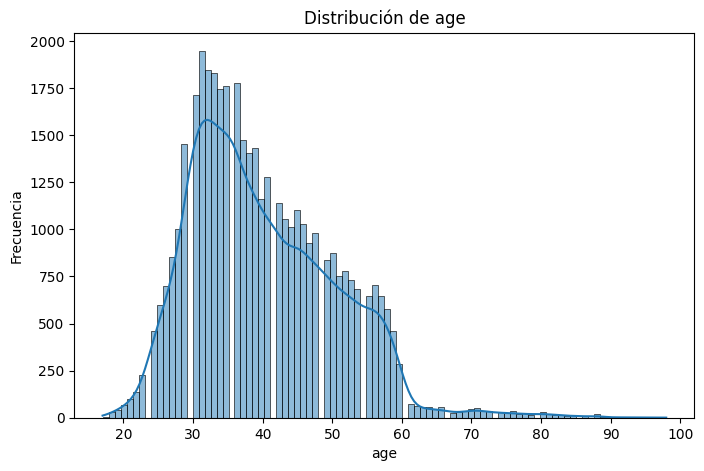

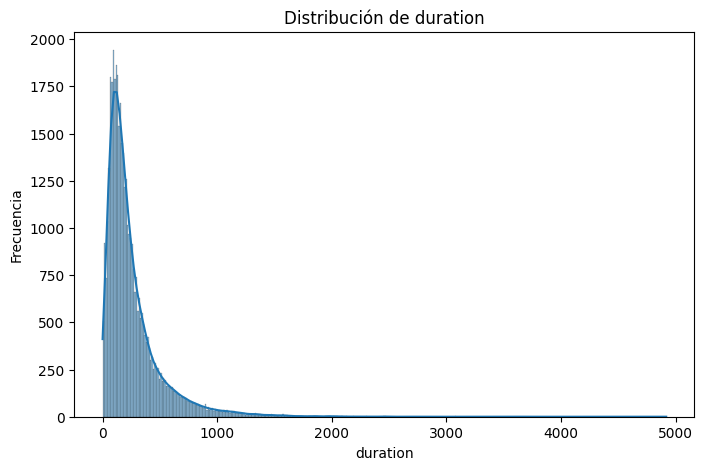

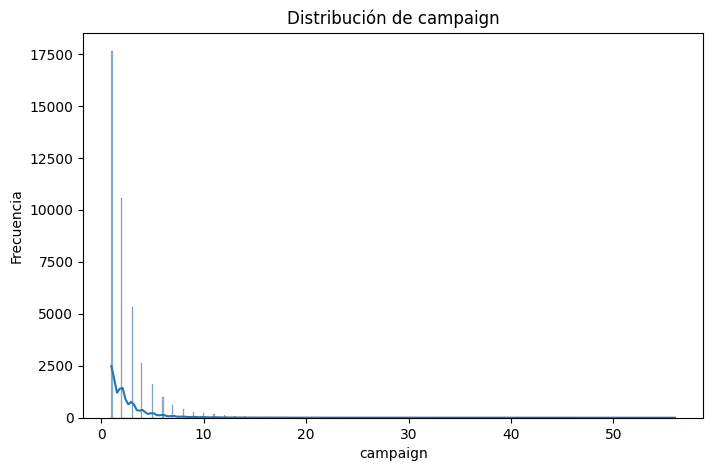

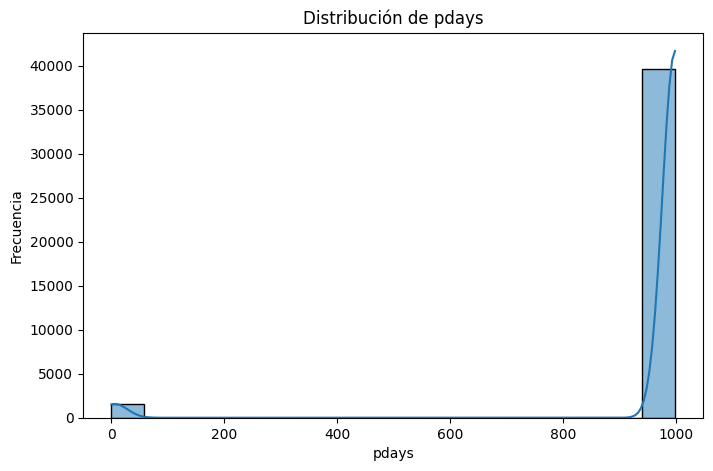

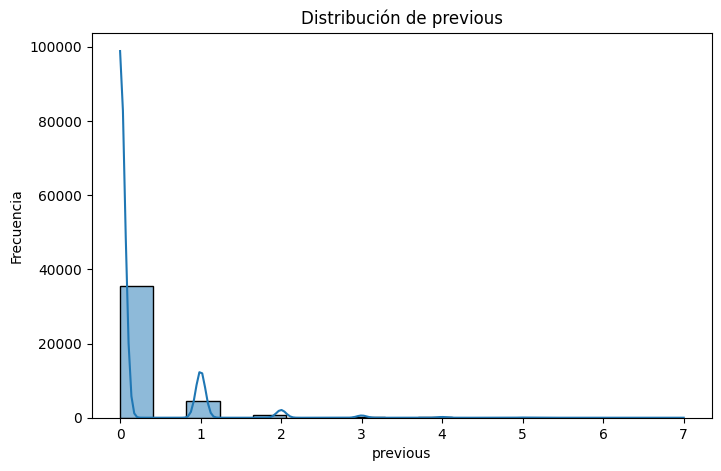

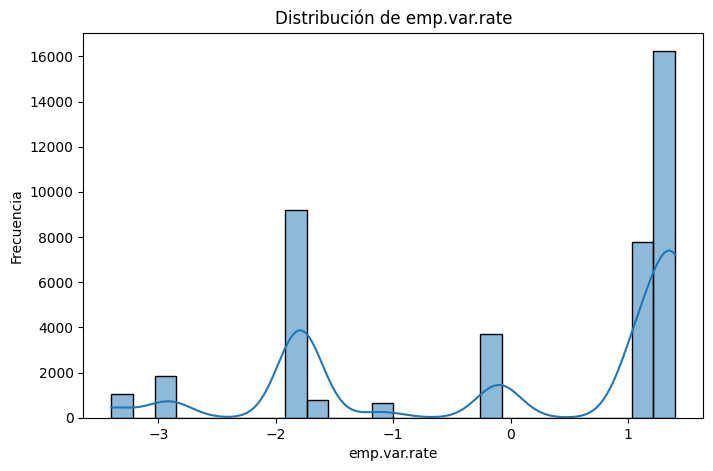

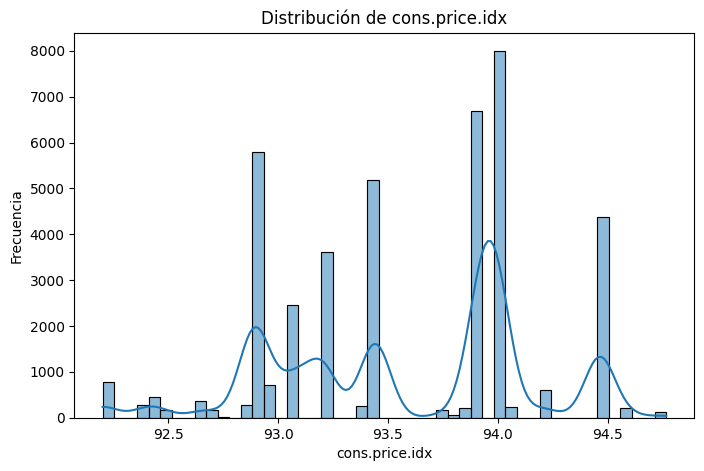

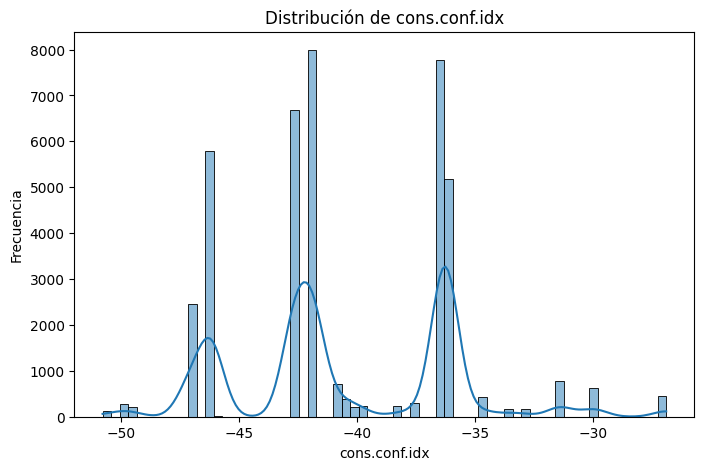

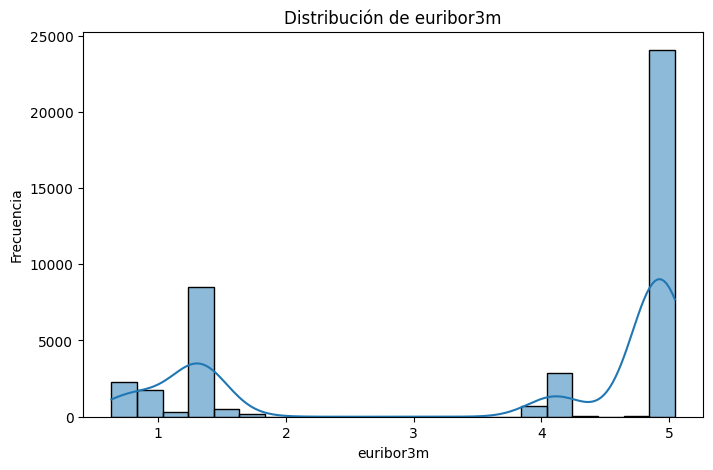

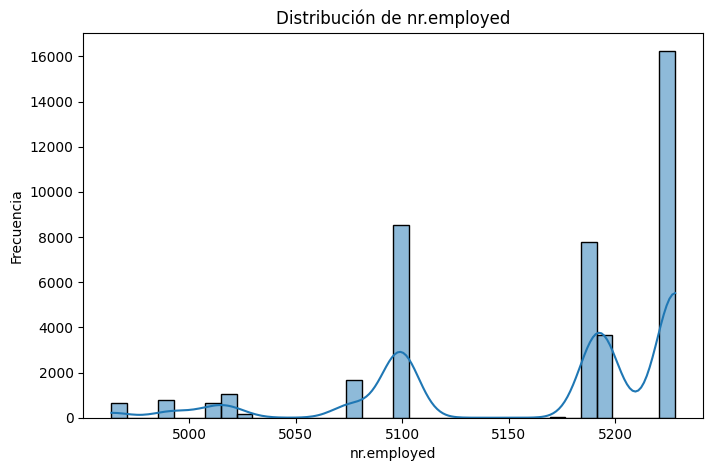

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


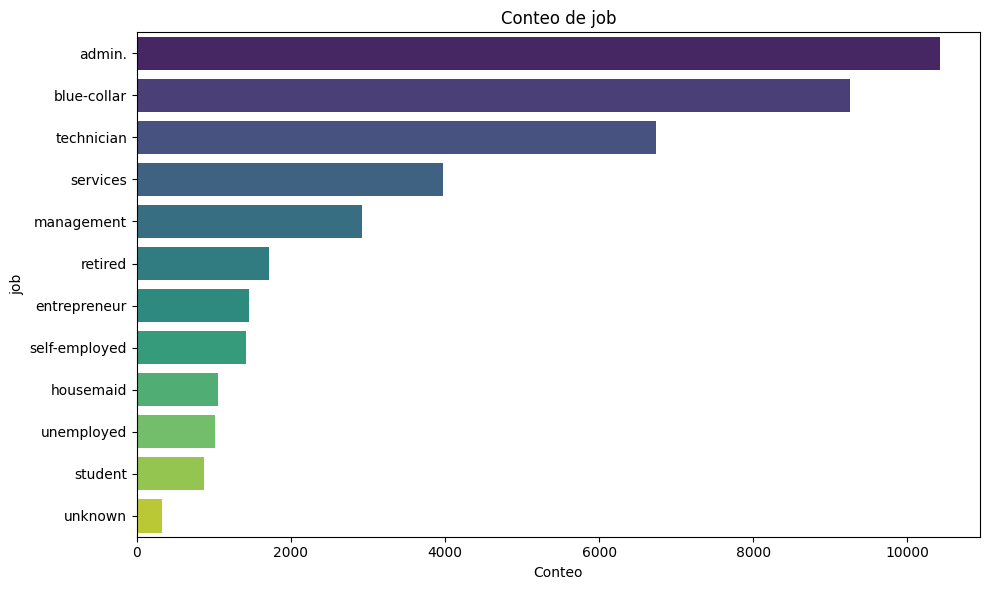

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


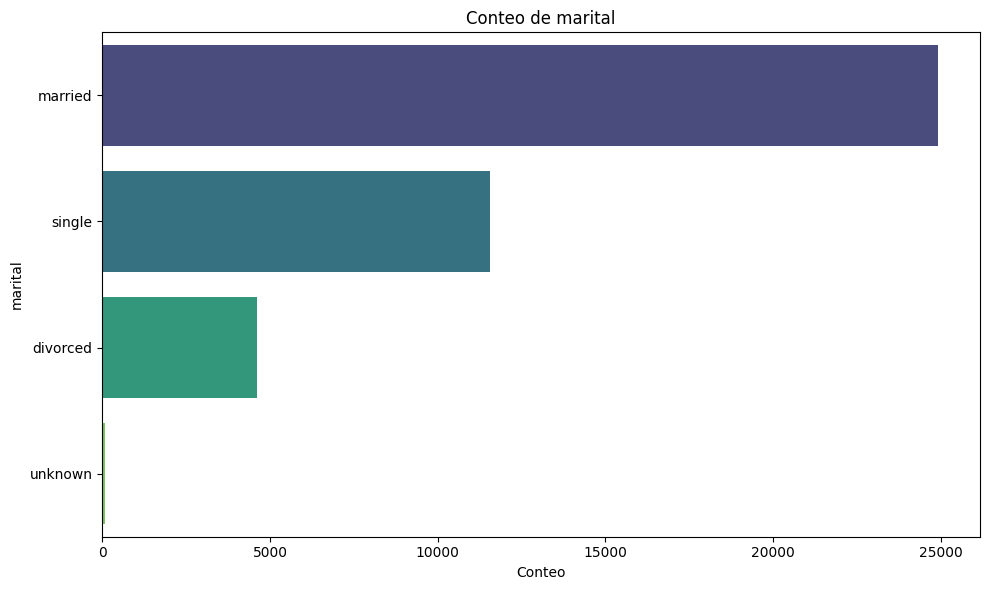

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


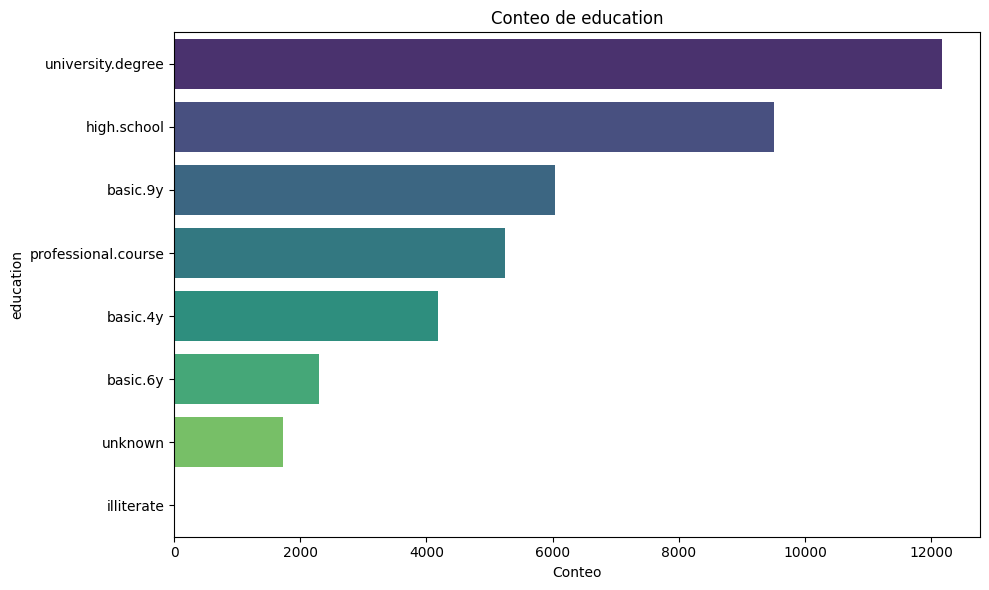

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


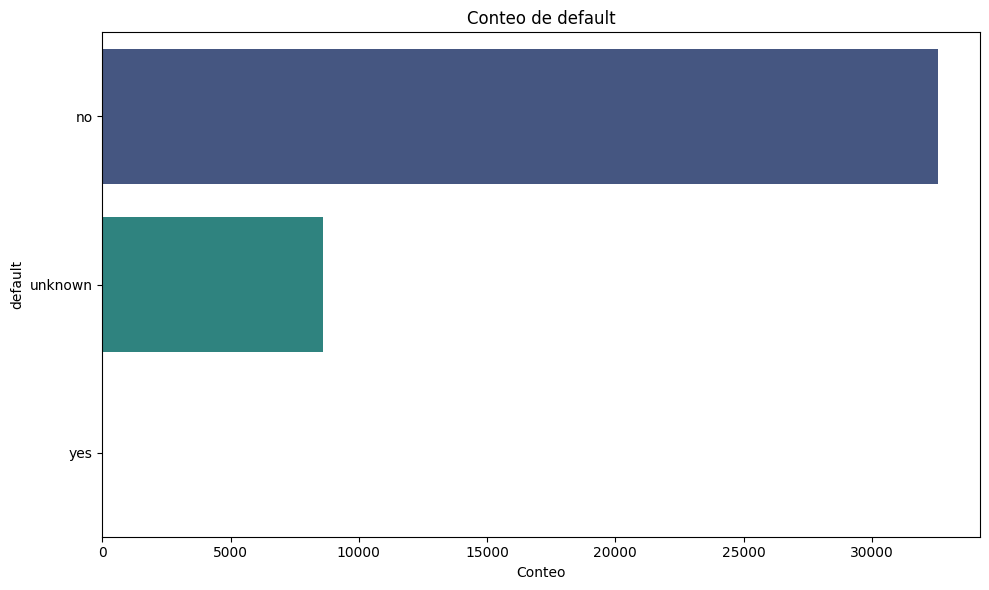

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


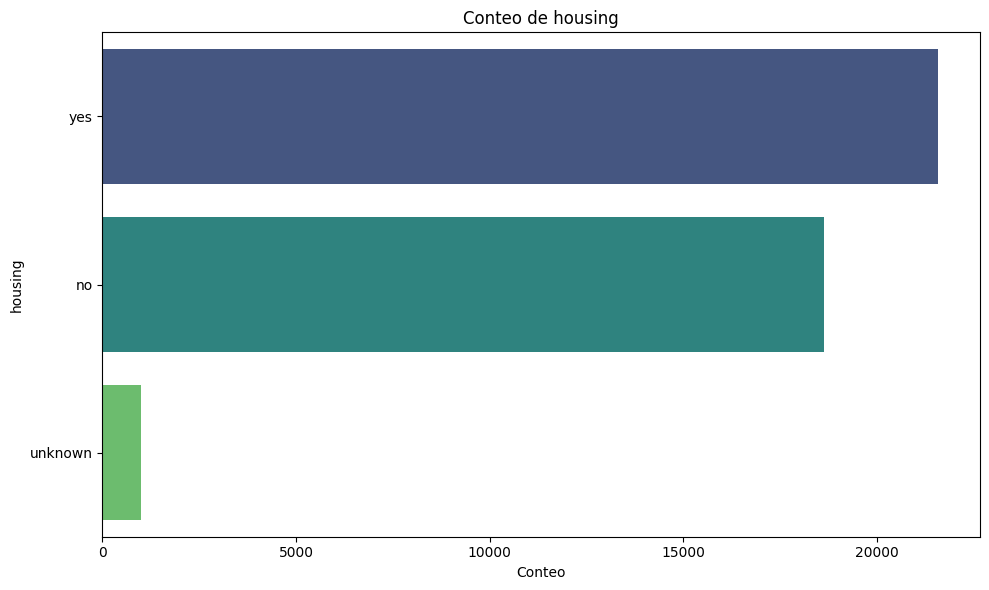

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


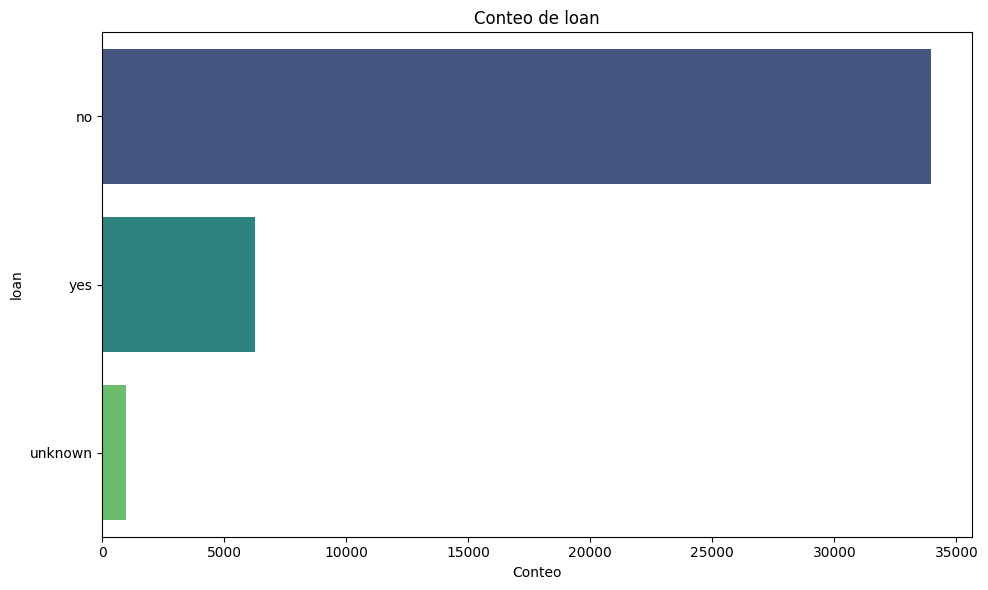

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


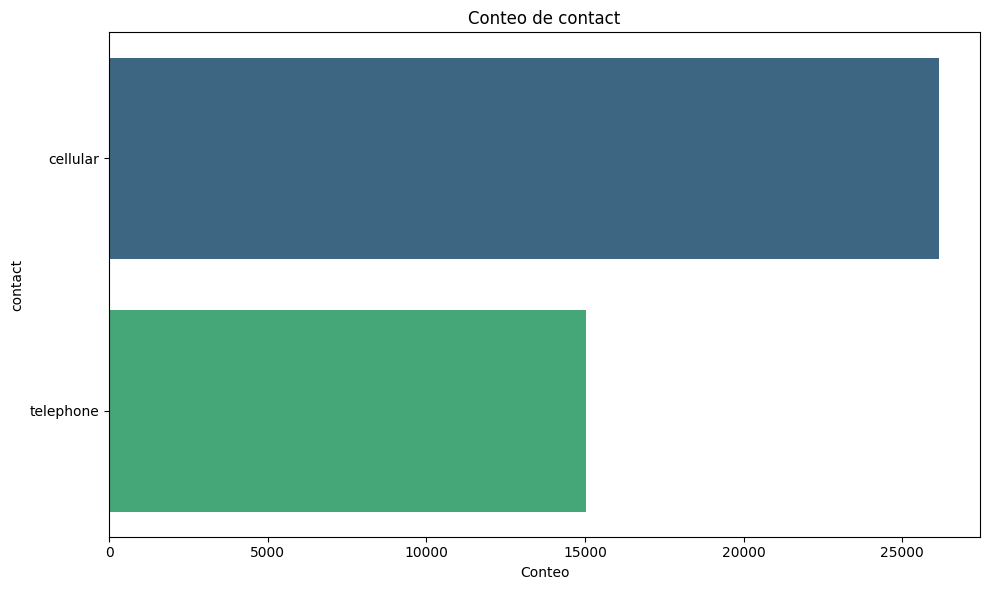

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


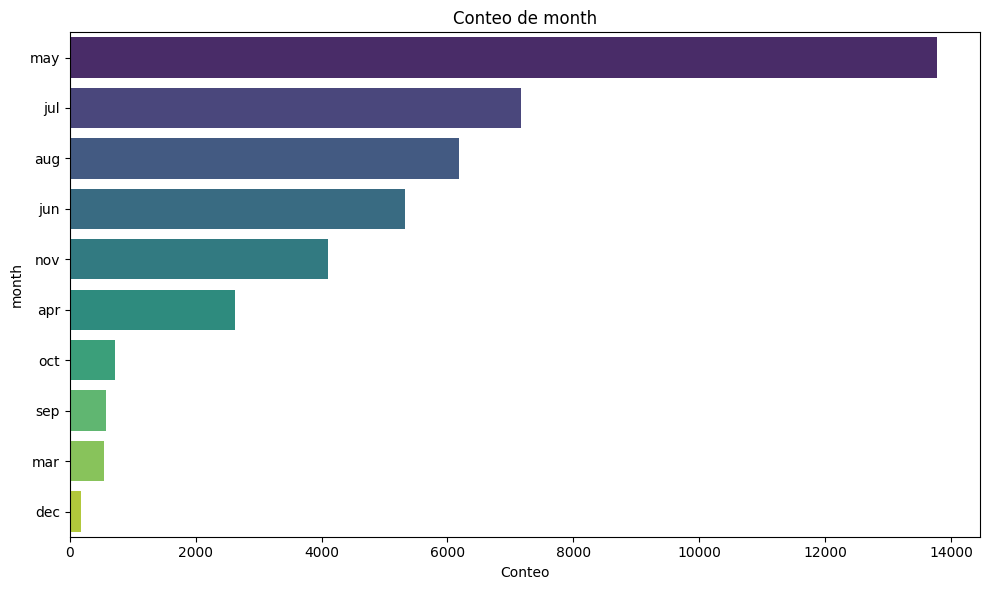

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


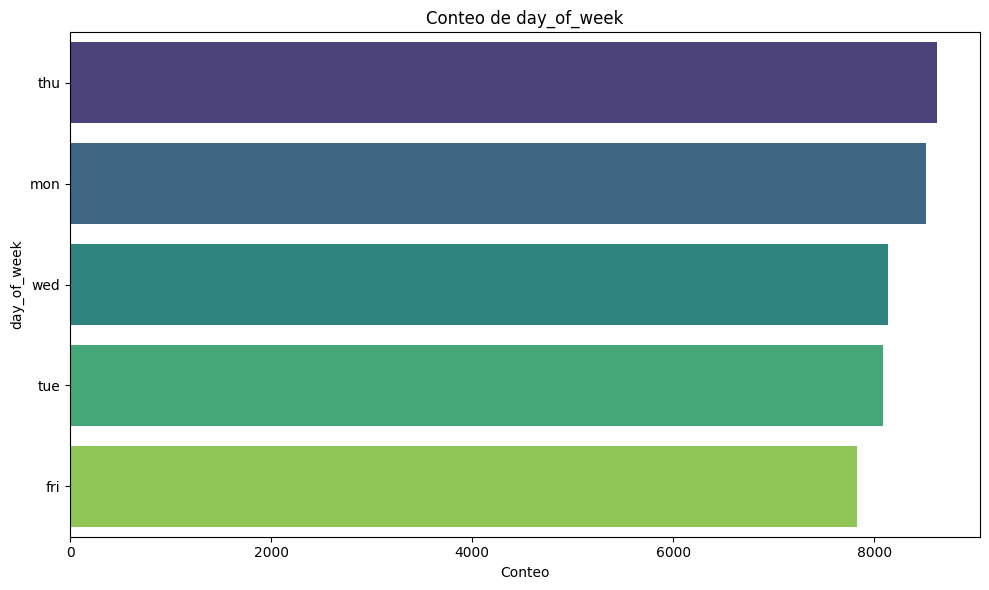

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


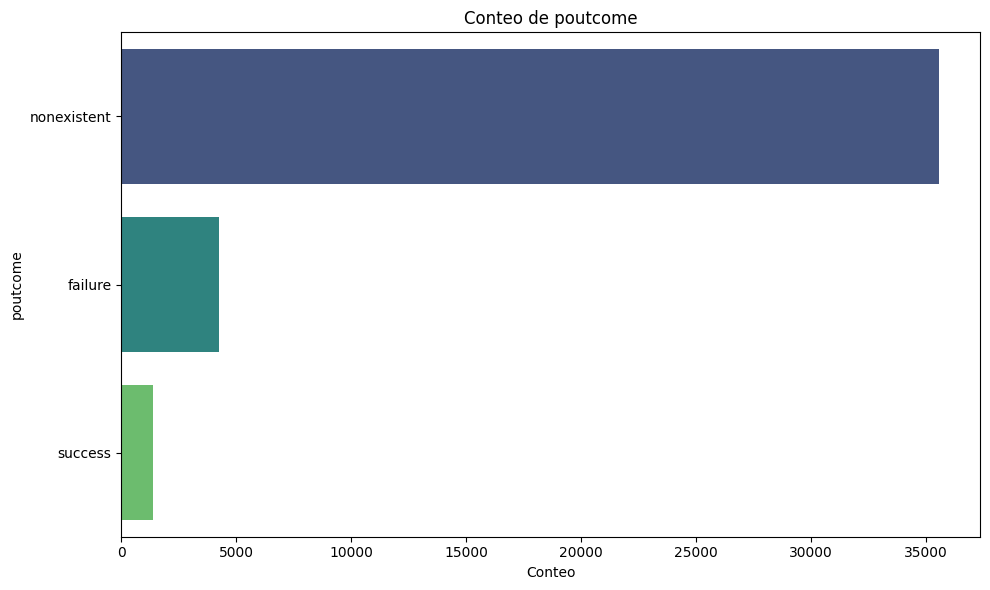

/tmp/ipykernel_2499/3648280214.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=self.df, y=col, order=self.df[col].value_counts().index, palette='viridis')


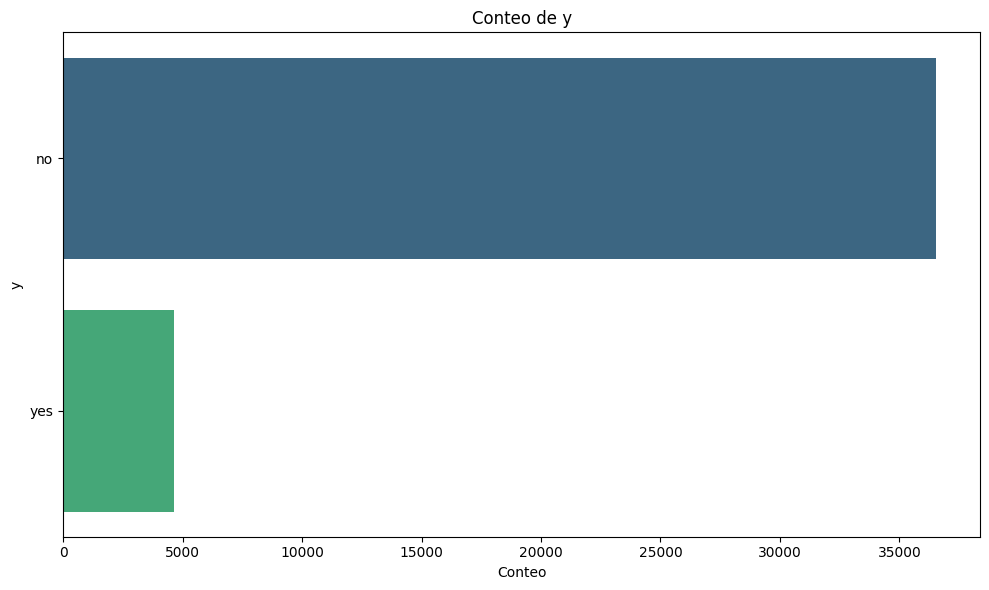

In [53]:
data_processor.visualize_distributions()

## 6. Análisis univariado

age
count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64


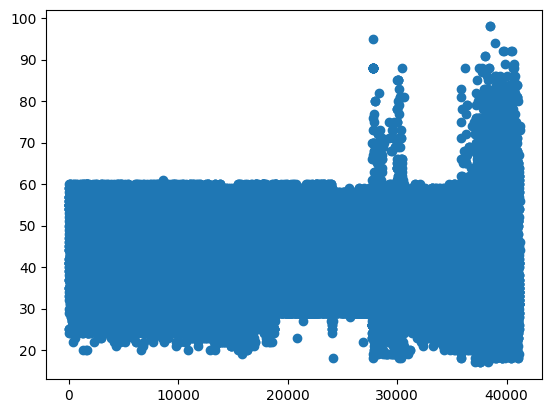

job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
count      41188
unique        12
top       admin.
freq       10422
Name: job, dtype: object


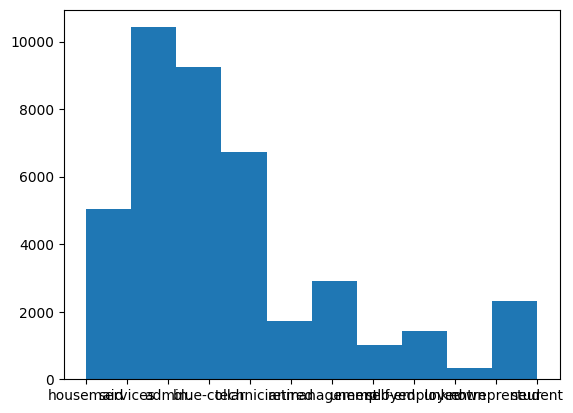

marital
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
['married' 'single' 'divorced' 'unknown']
count       41188
unique          4
top       married
freq        24928
Name: marital, dtype: object


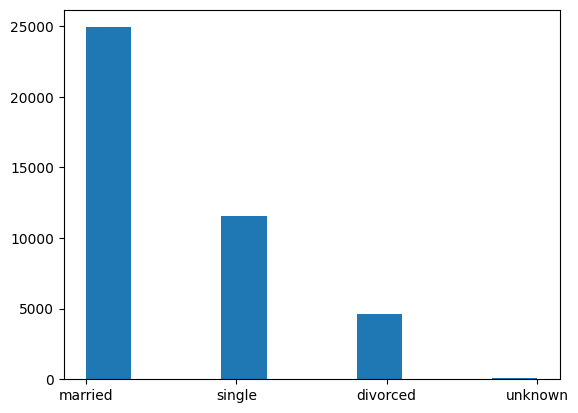

education
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
count                 41188
unique                    8
top       university.degree
freq                  12168
Name: education, dtype: object


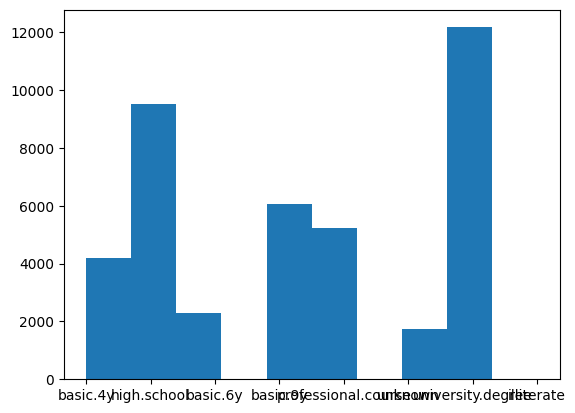

default
default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64
['no' 'unknown' 'yes']
count     41188
unique        3
top          no
freq      32588
Name: default, dtype: object


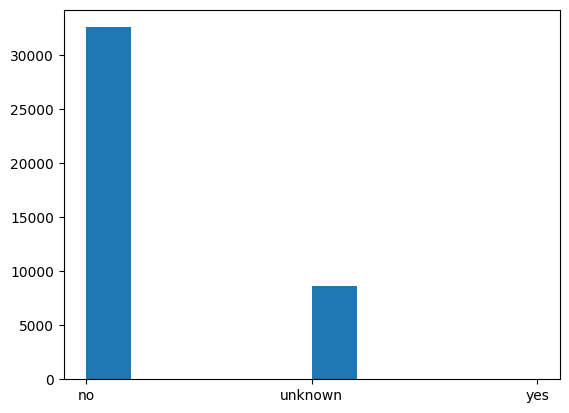

housing
housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64
['no' 'yes' 'unknown']
count     41188
unique        3
top         yes
freq      21576
Name: housing, dtype: object


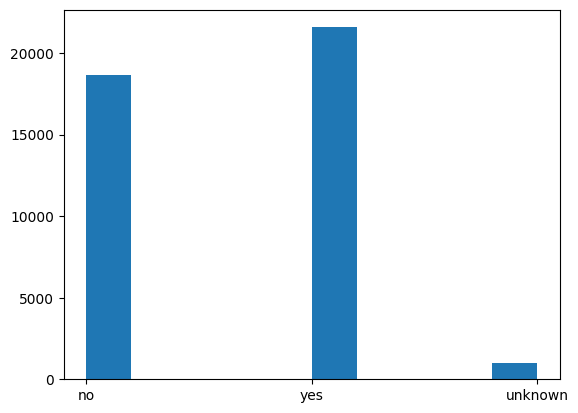

loan
loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64
['no' 'yes' 'unknown']
count     41188
unique        3
top          no
freq      33950
Name: loan, dtype: object


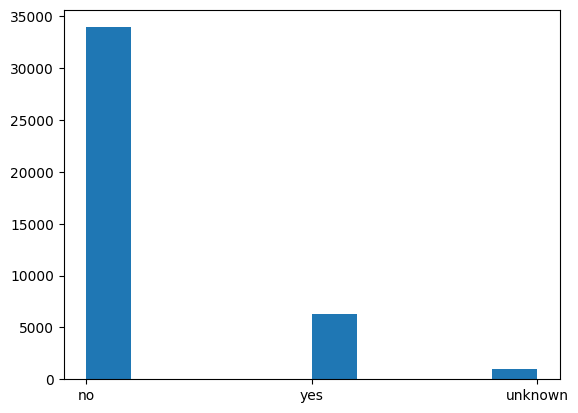

contact
contact
cellular     26144
telephone    15044
Name: count, dtype: int64
['telephone' 'cellular']
count        41188
unique           2
top       cellular
freq         26144
Name: contact, dtype: object


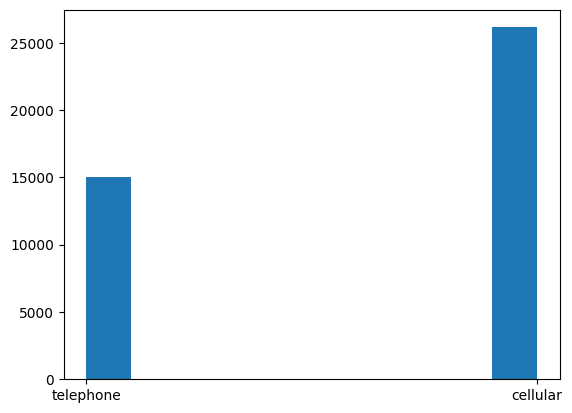

month
month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
count     41188
unique       10
top         may
freq      13769
Name: month, dtype: object


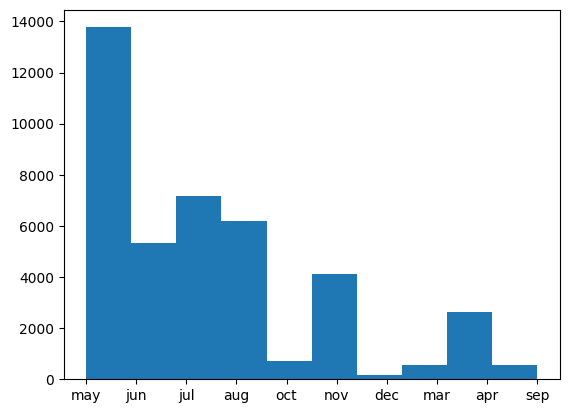

day_of_week
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64
['mon' 'tue' 'wed' 'thu' 'fri']
count     41188
unique        5
top         thu
freq       8623
Name: day_of_week, dtype: object


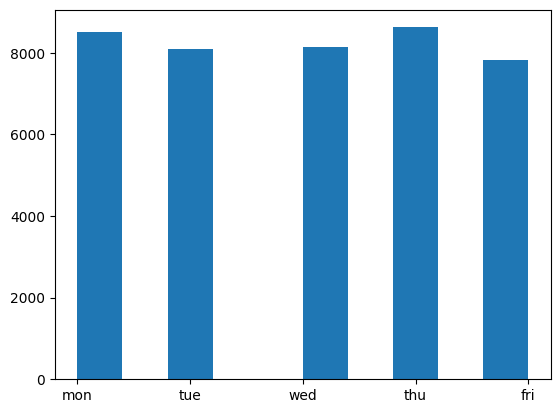

duration
count    41188.000000
mean       258.285010
std        259.279249
min          0.000000
25%        102.000000
50%        180.000000
75%        319.000000
max       4918.000000
Name: duration, dtype: float64


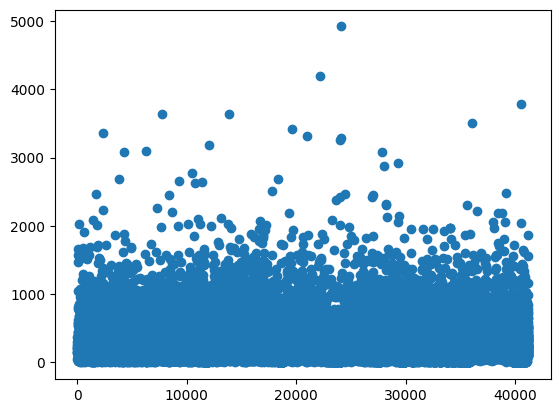

campaign
count    41188.000000
mean         2.567593
std          2.770014
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64


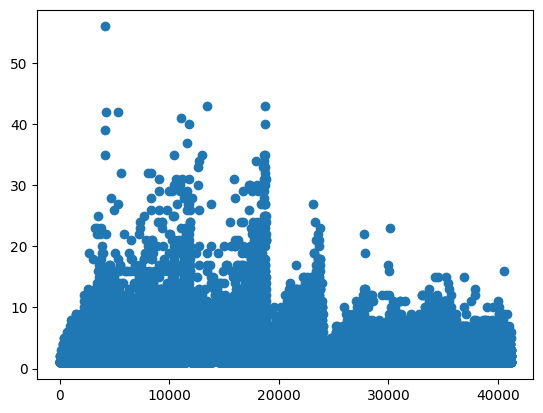

pdays
count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64


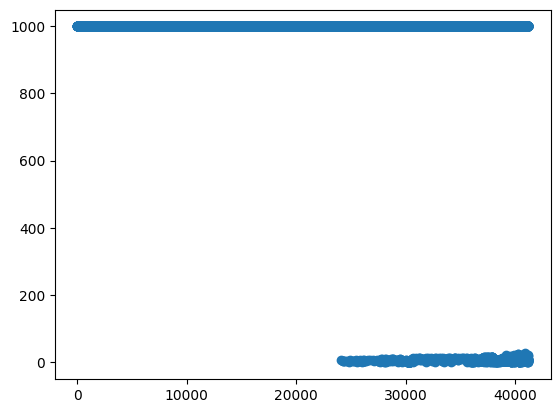

previous
count    41188.000000
mean         0.172963
std          0.494901
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          7.000000
Name: previous, dtype: float64


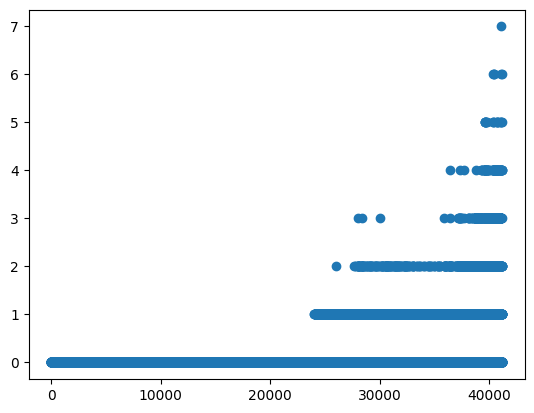

poutcome
poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64
['nonexistent' 'failure' 'success']
count           41188
unique              3
top       nonexistent
freq            35563
Name: poutcome, dtype: object


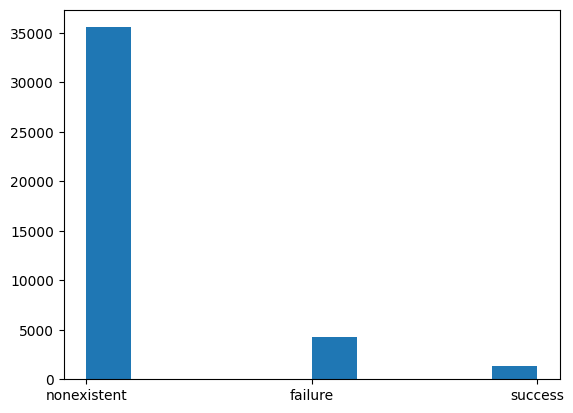

emp.var.rate
count    41188.000000
mean         0.081886
std          1.570960
min         -3.400000
25%         -1.800000
50%          1.100000
75%          1.400000
max          1.400000
Name: emp.var.rate, dtype: float64


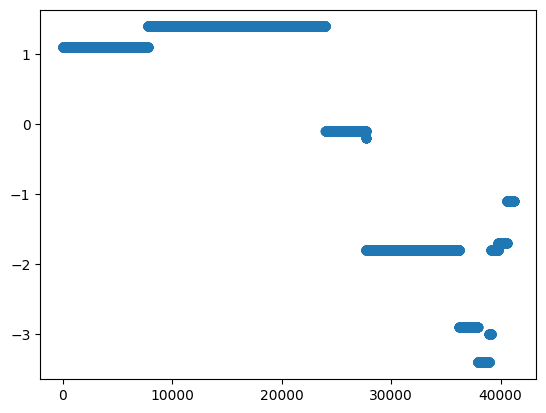

cons.price.idx
count    41188.000000
mean        93.575664
std          0.578840
min         92.201000
25%         93.075000
50%         93.749000
75%         93.994000
max         94.767000
Name: cons.price.idx, dtype: float64


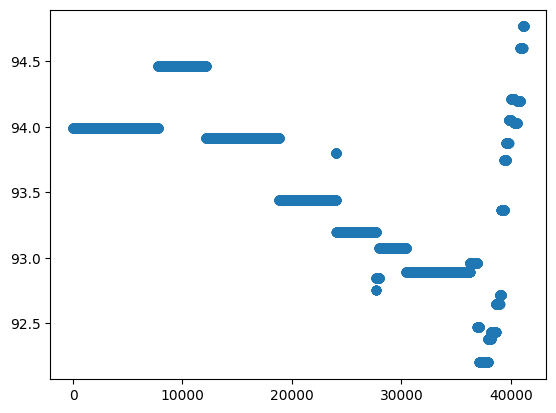

cons.conf.idx
count    41188.000000
mean       -40.502600
std          4.628198
min        -50.800000
25%        -42.700000
50%        -41.800000
75%        -36.400000
max        -26.900000
Name: cons.conf.idx, dtype: float64


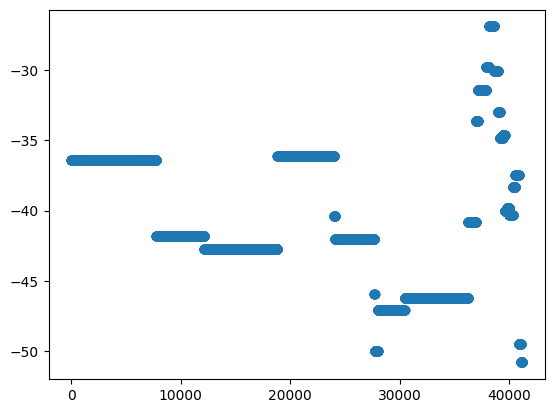

euribor3m
count    41188.000000
mean         3.621291
std          1.734447
min          0.634000
25%          1.344000
50%          4.857000
75%          4.961000
max          5.045000
Name: euribor3m, dtype: float64


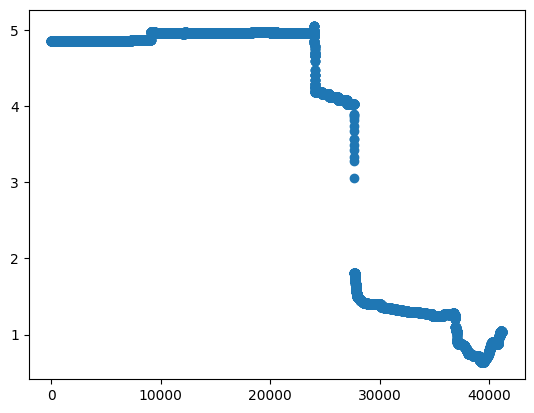

nr.employed
count    41188.000000
mean      5167.035911
std         72.251528
min       4963.600000
25%       5099.100000
50%       5191.000000
75%       5228.100000
max       5228.100000
Name: nr.employed, dtype: float64


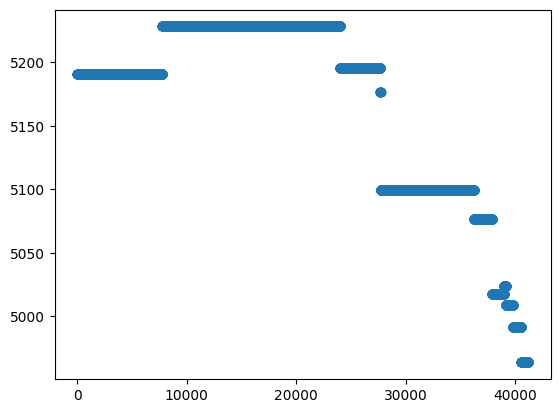

y
y
no     36548
yes     4640
Name: count, dtype: int64
['no' 'yes']
count     41188
unique        2
top          no
freq      36548
Name: y, dtype: object


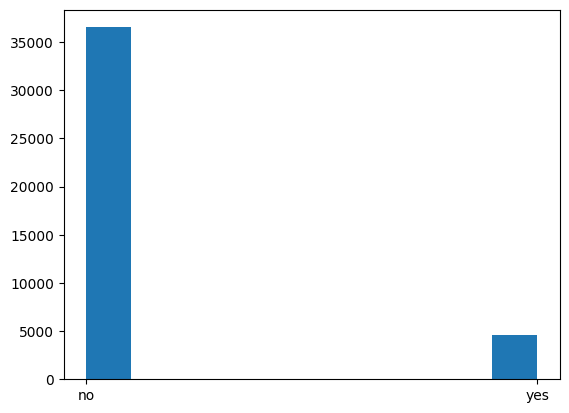

In [54]:
# Analizando cada variable de forma individual:
for columna in df.columns:

  if df[columna].dtype == "object":
    print( columna)
    print( df[columna].value_counts() )
    print( df[columna].unique() )
    print( df[columna].describe() )
    plt.figure()
    plt.hist( df[columna] )
    plt.show()
  else:
    print( columna)
    print( df[columna].describe() )
    plt.figure()
    plt.scatter( df.index,  df[columna])
    plt.show()

## 7. Análisis bivariado
Explorar relaciones entre variables clave. Utilizar gráficos como
countplot, boxplot, barplot o heatmap

###Comparativa de AGE vs Y
Analizo si la edad (AGE) tiene corelación con la aceptación o no de la campaña (Y).

In [55]:
age_bins = [0, 19, 29, 39, 49, 60, df['age'].max()]
age_labels = ['0-19', '20-29', '30-39', '40-49', '50-60', '60+']
df['rango_edad'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

age_grouped_data = df.groupby(['rango_edad', 'y']).size().unstack(fill_value=0)

print("Conteo de personas por grupo de edad que aceptaron la campaña ('y' = 'yes'):")
display(age_grouped_data['yes'])

Conteo de personas por grupo de edad que aceptaron la campaña ('y' = 'yes'):


/tmp/ipykernel_2499/2682438820.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grouped_data = df.groupby(['rango_edad', 'y']).size().unstack(fill_value=0)


,yes
rango_edad,
0-19,34
20-29,888
30-39,1715
40-49,834
50-60,755
60+,414


**Gráfico Barra**

/tmp/ipykernel_2499/3236065110.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_grouped_data = df.groupby(['age_group', 'y']).size().unstack(fill_value=0)


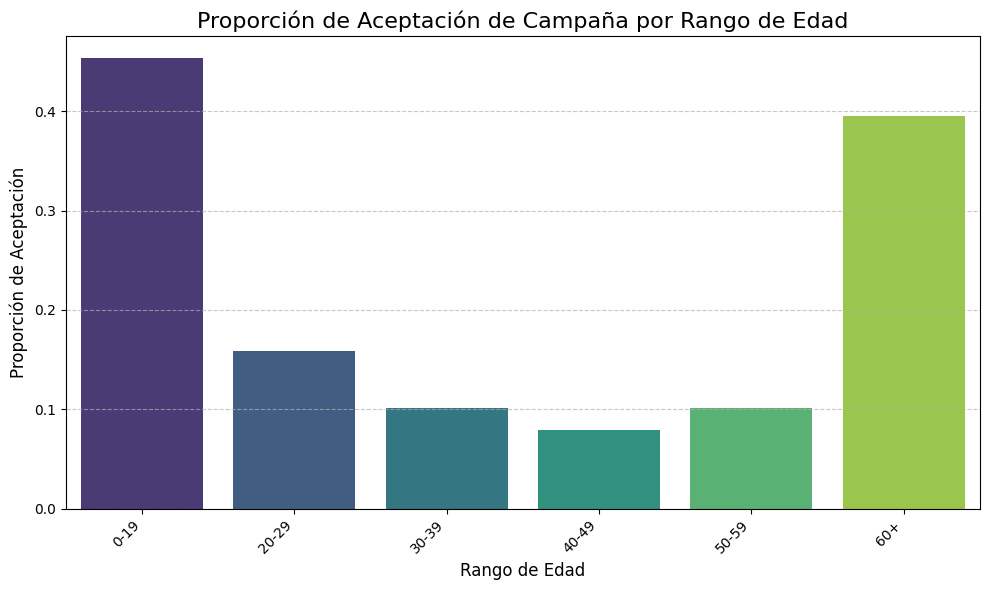

In [56]:
age_bins = [0, 19, 29, 39, 49, 59, df['age'].max()]
age_labels = ['0-19', '20-29', '30-39', '40-49', '50-59', '60+']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

age_grouped_data = df.groupby(['age_group', 'y']).size().unstack(fill_value=0)
age_grouped_data['yes_proportion'] = age_grouped_data['yes'] / (age_grouped_data['no'] + age_grouped_data['yes'])

plt.figure(figsize=(10, 6))
sns.barplot(data=age_grouped_data.reset_index(), x='age_group', y='yes_proportion', hue='age_group', palette='viridis', legend=False)
plt.title('Proporción de Aceptación de Campaña por Rango de Edad', fontsize=16)
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Proporción de Aceptación', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Comparativa de JOB vs Y
Analizo si el tipo del trabajo del cliente (JOB) tiene corelación con la aceptación o no de la campaña (Y).

In [57]:
df.groupby("job")["y"].value_counts()

job            y  
admin.         no     9070
               yes    1352
blue-collar    no     8616
               yes     638
entrepreneur   no     1332
               yes     124
housemaid      no      954
               yes     106
management     no     2596
               yes     328
retired        no     1286
               yes     434
self-employed  no     1272
               yes     149
services       no     3646
               yes     323
student        no      600
               yes     275
technician     no     6013
               yes     730
unemployed     no      870
               yes     144
unknown        no      293
               yes      37
Name: count, dtype: int64

**Lollipop Chart**

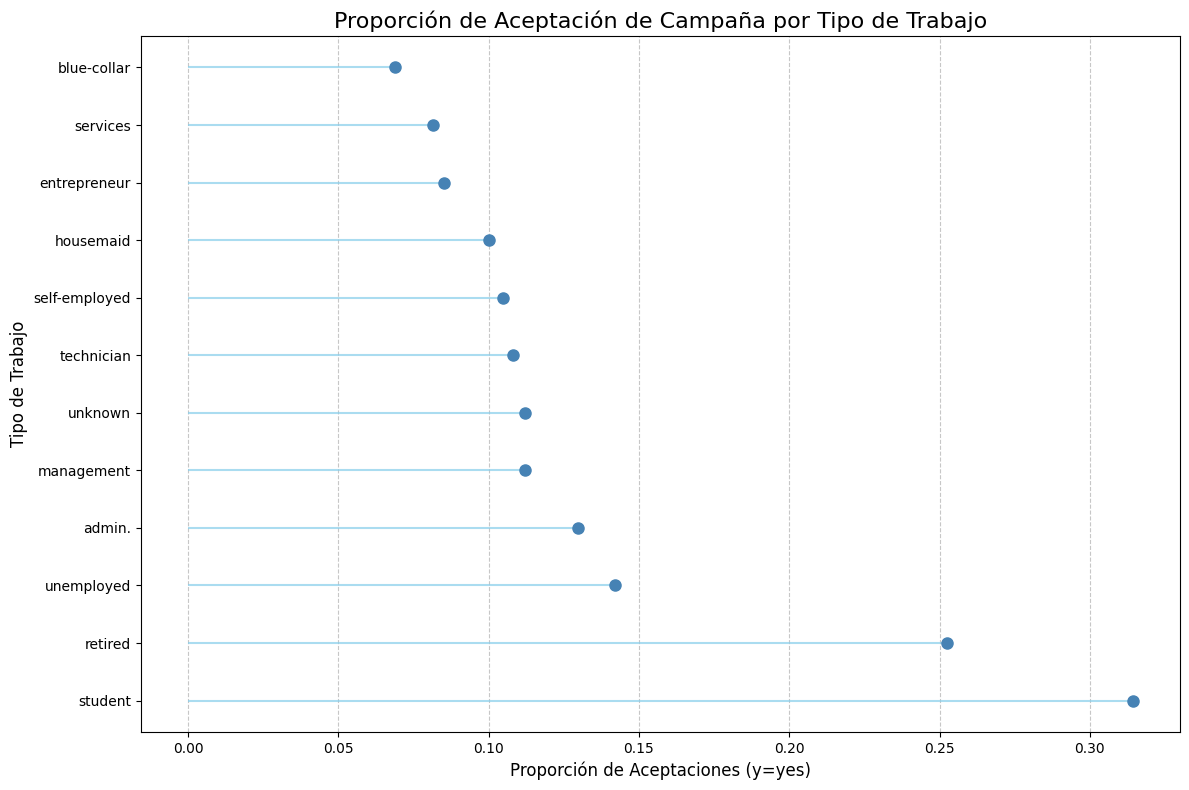

In [58]:
job_grouped_data = df.groupby(['job', 'y']).size().unstack(fill_value=0)

# Calculo la proporción de respuestas afirmativas para cada puesto de trabajo.
job_grouped_data['yes_proportion'] = job_grouped_data['yes'] / (job_grouped_data['no'] + job_grouped_data['yes'])

# Preparo los datos para su representación gráfica.
# Los ordeno por proporción para una mejor legibilidad.
plot_data = job_grouped_data.reset_index().sort_values(by='yes_proportion', ascending=False)

plt.figure(figsize=(12, 8))

# Creo lollipop chart
plt.hlines(y=plot_data['job'], xmin=0, xmax=plot_data['yes_proportion'], color='skyblue', alpha=0.7)
plt.plot(plot_data['yes_proportion'], plot_data['job'], "o", markersize=8, color='steelblue', alpha=1)

plt.title('Proporción de Aceptación de Campaña por Tipo de Trabajo', fontsize=16)
plt.xlabel('Proporción de Aceptaciones (y=yes)', fontsize=12)
plt.ylabel('Tipo de Trabajo', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Comparativa de MARITAL vs Y
Analizo si la estado civil del cliente (MARITAL) tiene corelación con la aceptación o no de la campaña (Y).

In [59]:
df.groupby("marital")["y"].value_counts()

marital   y  
divorced  no      4136
          yes      476
married   no     22396
          yes     2532
single    no      9948
          yes     1620
unknown   no        68
          yes       12
Name: count, dtype: int64

**Gráfico de Pastel**

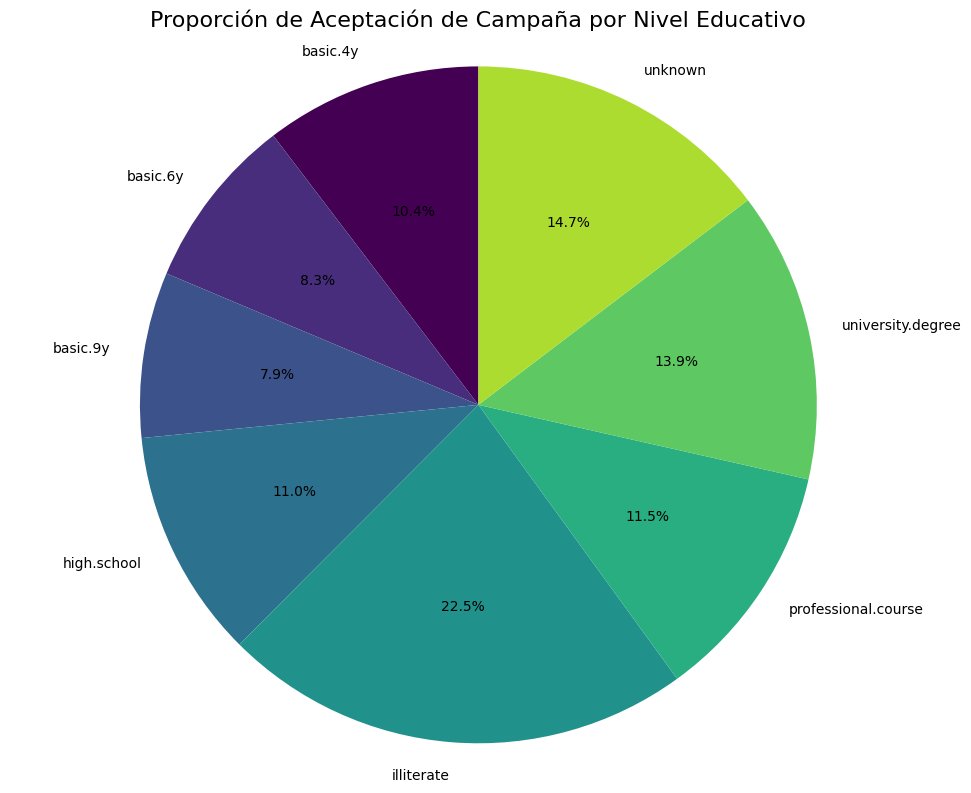

In [60]:
education_grouped_data = df.groupby(['education', 'y']).size().unstack(fill_value=0)

# Calculo la proporción de respuestas afirmativas para cada estado civil.
education_grouped_data['yes_proportion'] = education_grouped_data['yes'] / (education_grouped_data['no'] + education_grouped_data['yes'])

# Preparo los datos para graficar
plot_data_education = education_grouped_data.reset_index()

plt.figure(figsize=(10, 8))

# Obtengo una paleta de colores y creo una lista de colores según el número de categorías
colors = cm.viridis(plot_data_education['education'].index / len(plot_data_education['education']))

plt.pie(plot_data_education['yes_proportion'], labels=plot_data_education['education'], autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Proporción de Aceptación de Campaña por Nivel Educativo', fontsize=16)
plt.axis('equal') # La proporción de aspecto 'equal' garantiza que el pastel se dibuje como un círculo.
plt.tight_layout()
plt.show()

###Comparativa de EDUCATION vs Y
Analizo si la nivel educativo del cliente (EDUCATIONAL) tiene corelación con la aceptación o no de la campaña (Y).

In [61]:
df.groupby("education")["y"].value_counts()

education            y  
basic.4y             no      3748
                     yes      428
basic.6y             no      2104
                     yes      188
basic.9y             no      5572
                     yes      473
high.school          no      8484
                     yes     1031
illiterate           no        14
                     yes        4
professional.course  no      4648
                     yes      595
university.degree    no     10498
                     yes     1670
unknown              no      1480
                     yes      251
Name: count, dtype: int64

**Mapa de Calor (Heatmap)**

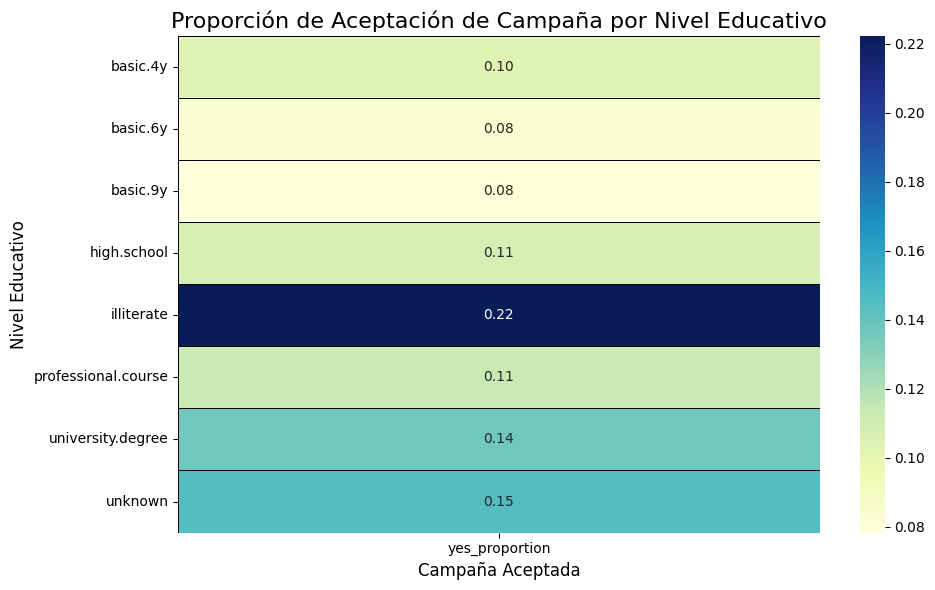

In [62]:
education_grouped_data = df.groupby(['education', 'y']).size().unstack(fill_value=0)

#Calculo la proporción de respuestas afirmativas para cada nivel educativo.
education_grouped_data['yes_proportion'] = education_grouped_data['yes'] / (education_grouped_data['no'] + education_grouped_data['yes'])

# Preparo los datos para la representación gráfica (convierto
# las series a DataFrame y renombrar las columnas)
plot_data_heatmap = education_grouped_data['yes_proportion'].reset_index()
plot_data_heatmap.columns = ['education', 'yes_proportion']

plt.figure(figsize=(10, 6))
# Utilizo mapa de calor para visualizar las proporciones.
sns.heatmap(
    plot_data_heatmap.set_index('education'), # Establece EDUCATION como índice para las filas del mapa de calor
    annot=True,        # Muestra los valores de proporción en el mapa de calor.
    fmt=".2f",         # Formateo las anotaciones a dos decimales.
    cmap="YlGnBu",     # Mapa de colores para el mapa de calor
    linewidths=.5,     # Agrega líneas entre las celdas
    linecolor='black'
)

plt.title('Proporción de Aceptación de Campaña por Nivel Educativo', fontsize=16)
plt.xlabel('Campaña Aceptada', fontsize=12) # Esto se corregirá con el nombre de columna 'yes_proportion'.
plt.ylabel('Nivel Educativo', fontsize=12)
plt.yticks(rotation=0) # Para que las etiquetas educativas sean horizontales.
plt.tight_layout()
plt.show()

## 8. Visualización

In [63]:
# Generar al menos 3 visualizaciones claras y explicadas, combinando variables numéricas y categóricas. Integrar Matplotlib o Plotly.



###Tasa de Suscripción por Categoría de Trabajo

Esta visualización muestra la proporción de clientes que aceptaron la campaña ('yes') para cada tipo de trabajo. Nos ayuda a identificar qué profesiones tienen una mayor o menor propensión a suscribirse a la oferta del banco.

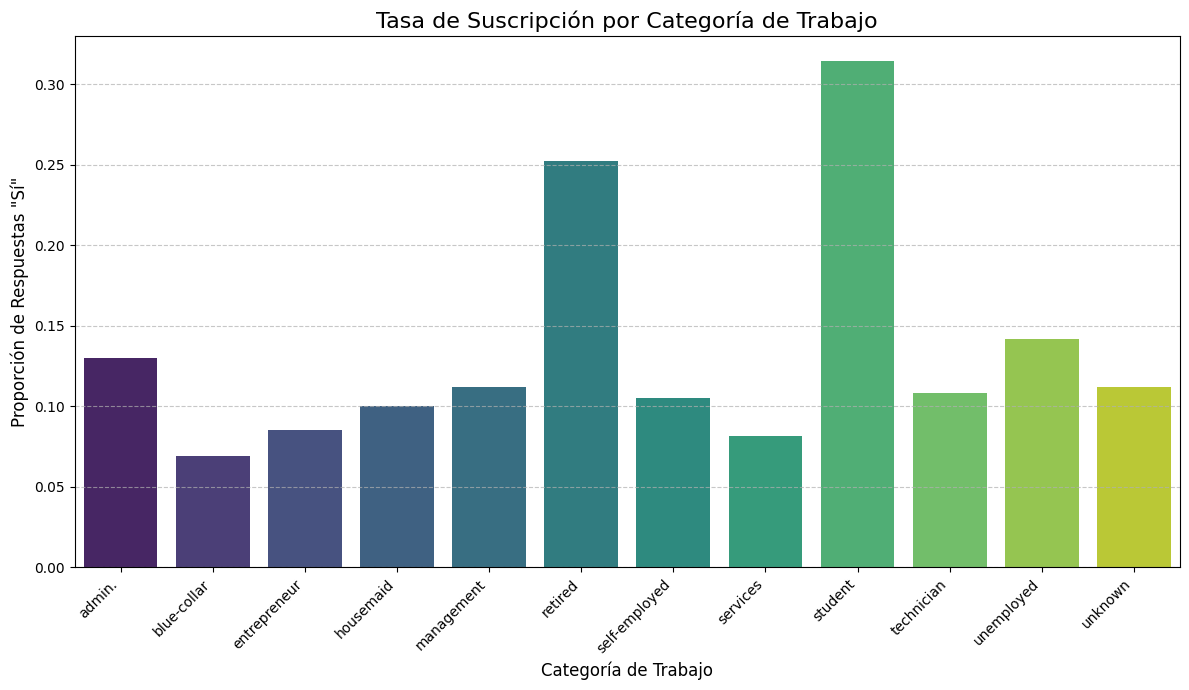

In [64]:
job_grouped_data = df.groupby(['job', 'y']).size().unstack(fill_value=0)
job_grouped_data['yes_proportion'] = job_grouped_data['yes'] / (job_grouped_data['no'] + job_grouped_data['yes'])

plt.figure(figsize=(12, 7))
sns.barplot(data=job_grouped_data.reset_index(), x='job', y='yes_proportion', hue='job', palette='viridis', legend=False)
plt.title('Tasa de Suscripción por Categoría de Trabajo', fontsize=16)
plt.xlabel('Categoría de Trabajo', fontsize=12)
plt.ylabel('Proporción de Respuestas "Sí"', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Distribución de la Duración de la Llamada por Aceptación de Campaña

Este diagrama de caja (boxplot) compara la duración de la última llamada de contacto con el resultado de la campaña ('y'). Permite observar si existe una diferencia significativa en la duración de las llamadas entre los clientes que aceptaron y los que no aceptaron la oferta, sugiriendo la importancia del tiempo de interacción.

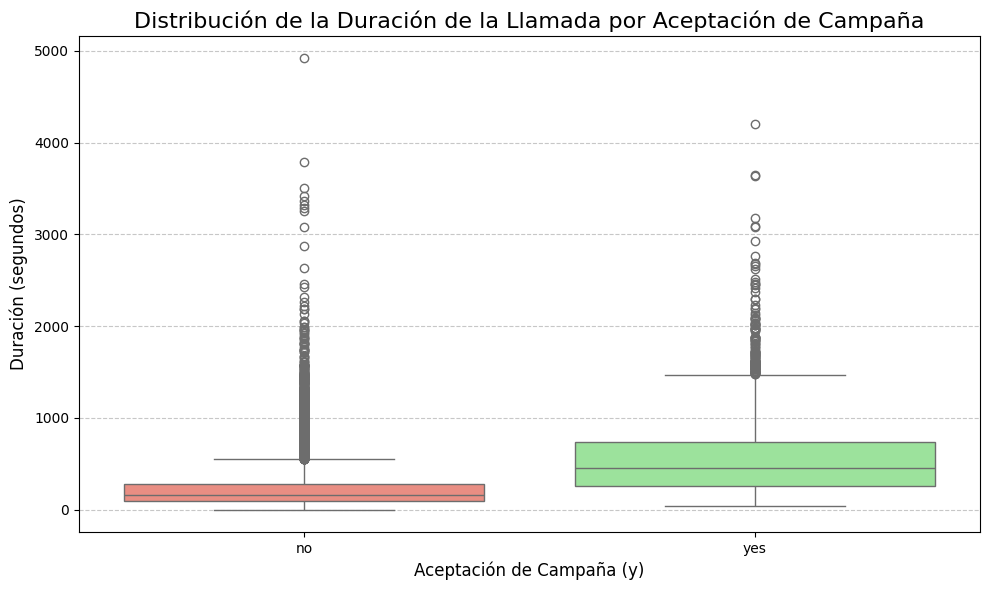

In [65]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='y', y='duration', hue='y', palette={'yes': 'lightgreen', 'no': 'salmon'}, legend=False)
plt.title('Distribución de la Duración de la Llamada por Aceptación de Campaña', fontsize=16)
plt.xlabel('Aceptación de Campaña (y)', fontsize=12)
plt.ylabel('Duración (segundos)', fontsize=12)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

###Tasa de Éxito según el Resultado de la Campaña Anterior

Este gráfico de barras muestra cómo el resultado de campañas anteriores ('poutcome') influye en la tasa de éxito de la campaña actual. Es útil para entender si los clientes que tuvieron un resultado positivo en el pasado son más propensos a aceptar ofertas futuras.

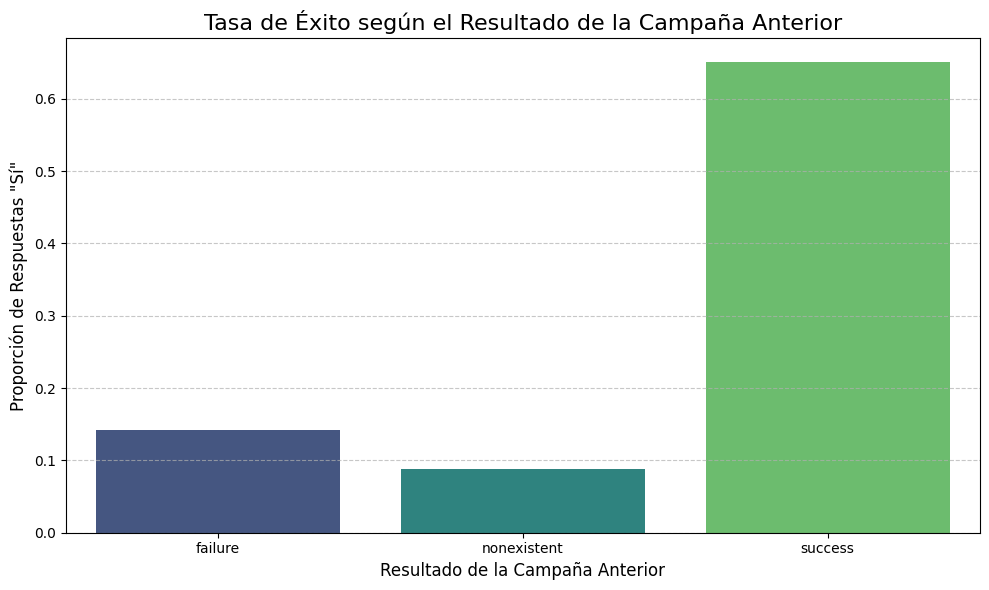

In [66]:
poutcome_data = df.groupby(['poutcome', 'y']).size().unstack(fill_value=0)
poutcome_data['yes_proportion'] = poutcome_data['yes'] / (poutcome_data['no'] + poutcome_data['yes'])

plt.figure(figsize=(10, 6))
sns.barplot(data=poutcome_data.reset_index(), x='poutcome', y='yes_proportion', hue='poutcome', palette='viridis', legend=False)
plt.title('Tasa de Éxito según el Resultado de la Campaña Anterior', fontsize=16)
plt.xlabel('Resultado de la Campaña Anterior', fontsize=12)
plt.ylabel('Proporción de Respuestas "Sí"', fontsize=12)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 9. Conclusiones

- Redactar 5 observaciones principales sobre las relaciones encontradas.
- Explicar cómo el EDA podría guiar decisiones futuras sin usar modelos predictivos.

### Observaciones Principales:

1.  **La edad sí importa:** Hemos visto que los extremos de edad, tanto los más jóvenes (0-19) como los mayores de 60 años, muestran una tendencia significativamente más alta a aceptar la campaña. Esto contrasta con los grupos de mediana edad, que parecen ser menos receptivos. Quizás las motivaciones o necesidades de estos grupos son distintas.

2.  **Profesiones más receptivas:** Algunas ocupaciones, como los estudiantes y los jubilados, son notablemente más propensas a decir "sí" a la campaña. Por otro lado, las personas con trabajos como 'blue-collar' (obreros) o 'services' (servicios) tienen una tasa de aceptación considerablemente menor. Esto sugiere que el mensaje o la oferta no resuenan igual en todos los sectores profesionales.

3.  **La duración del contacto es clave:** Hay una relación muy clara entre el tiempo que dura la llamada de contacto y la probabilidad de que el cliente acepte la campaña. Las personas que finalmente dicen "sí" suelen haber tenido interacciones telefónicas mucho más largas. Esto indica que un mayor diálogo o una explicación más detallada puede ser crucial.

4.  **El historial de la campaña anterior predice el éxito:** Si un cliente ya tuvo una "success" (éxito) en una campaña anterior, la probabilidad de que acepte la actual es altísima. Esto es un indicador muy fuerte de que los clientes con experiencias positivas previas son mucho más fáciles de convencer, mientras que un resultado de "failure" (fracaso) o "nonexistent" (inexistente) reduce drásticamente las posibilidades.

5.  **No es una campaña universal:** En general, se percibe que la campaña no tiene un impacto uniforme en todos los segmentos de clientes. Las diferencias en la tasa de aceptación según la edad, la profesión, el estado civil o el nivel educativo son bastante marcadas. Esto nos dice que una estrategia de "cafetería para todos" probablemente no es la más efectiva.

### Cómo el EDA puede guiar decisiones futuras sin modelos predictivos

Basándonos en todo lo que hemos descubierto en este análisis exploratorio de datos **(EDA)**, te explico cómo podemos tomar decisiones importantes para el futuro sin necesidad de recurrir a complejos modelos predictivos. La clave está en entender muy bien los patrones y las relaciones que ya existen en nuestros datos:

1.  **¿A quién hablamos y cómo?** Al ver qué grupos de edad o qué tipos de trabajo responden mejor a la campaña, podemos afinar mucho a quién dirigirnos. No necesitamos adivinar quién aceptará; ya sabemos, por ejemplo, que los estudiantes o los jubilados son más receptivos. Así, podemos invertir tiempo y recursos en ellos, o adaptar el mensaje para que les resulte más interesante.

2.  **La importancia del 'cuánto' en la conversación:** La duración de la llamada no es un detalle menor. Si observamos que las conversaciones que terminan en 'sí' son, de media, más largas, esto nos dice algo crucial: vale la pena dedicarle tiempo al cliente. Esto puede llevar a replantear la capacitación de los agentes, incentivándolos a mantener diálogos más profundos y no a despachar llamadas rápidamente.

3.  **Aprovechando la experiencia pasada:** El hecho de que un éxito en una campaña anterior sea un gran predictor de éxito actual es una mina de oro. No hay que ser un adivino para saber que si a alguien ya le fue bien, es muy probable que le interese repetir. Podemos priorizar a estos clientes, quizás con ofertas especiales o un trato preferencial, sin necesidad de un algoritmo complejo que nos lo 'prediga'.

4.  **Si no funciona aquí, quizá sí allí:** Cuando vemos que ciertos estados civiles o niveles educativos no responden tan bien, o que un mes específico tiene muy poca tasa de éxito, esto nos da una pista clara: la estrategia actual no es universal. Podemos decidir probar otros enfoques con esos grupos o, incluso, dejar de invertir tanto en ellos si no son rentables. Es una forma de optimizar los recursos basándonos en lo que ya sabemos, no en lo que esperamos que suceda.

Podríamos decir que el EDA es como tener un mapa muy detallado de lo que ya ha ocurrido. Nos permite ver las rutas que funcionaron y las que no, identificar los atajos y los obstáculos. Con ese mapa en mano, podemos trazar nuevas estrategias con mucha más confianza, sin tener que predecir cada giro del camino, sino simplemente usando la sabiduría que nos dan los datos históricos.